# Lecture 5: Classification Fundamentals
### NLP Course 2027

---

## Learning Outcomes
- Understand text classification problems and their structure
- Extract features from text for machine learning
- Train and evaluate Naive Bayes classifiers with NLTK
- Build scikit-learn pipelines for text classification

**Primary References:** *NLP with Python* Ch.6 | *Practical NLP* Ch.4

## 1. What Is Text Classification?

Text classification assigns predefined **categories** to text documents.

```
Input Text            Classifier        Output Category
─────────────────────────────────────────────────────────
'Great product!'  →  [Sentiment]   →   POSITIVE
'Buy now! Free!'  →  [Spam Det.]   →   SPAM
'Tech layoffs..'  →  [Topic]       →   BUSINESS
'How do I login?' →  [Intent]      →   SUPPORT_REQUEST
```

### Common Text Classification Tasks
| Task | Input | Output Classes |
|------|-------|----------------|
| Sentiment Analysis | Review text | Positive / Negative / Neutral |
| Spam Detection | Email | Spam / Ham |
| Topic Classification | News article | Sports, Politics, Tech, ... |
| Intent Detection | User query | Buy, Search, Support, ... |
| Language Identification | Any text | EN, FR, DE, ZH, ... |

## 2. Feature Extraction for Text

ML models need **numerical features**. For text:

### Bag of Words (BoW)
```
Doc 1: 'the cat sat on the mat'
Vocabulary: [cat, dog, log, mat, on, sat, the]
Doc 1 vector: [1, 0, 0, 1, 1, 1, 2]
```

### Binary Features (NLTK style)
```python
features = {'contains(excellent)': True, 'contains(terrible)': False, ...}
```

### TF-IDF
Weights words by importance: frequent in doc, rare in corpus → high score.

In [1]:
import nltk
from nltk.corpus import movie_reviews
import random

nltk.download('movie_reviews', quiet=True)

# Load movie reviews: 2000 reviews, pos/neg
documents = [
    (list(movie_reviews.words(fileid)), category)
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]
random.shuffle(documents)
print(f'Total documents: {len(documents)}')
print(f'Sample (first 20 words): {documents[0][0][:20]}')
print(f'Category: {documents[0][1]}')

Total documents: 2000
Sample (first 20 words): ['the', 'makers', 'of', 'jurassic', 'park', '&', 'the', 'director', 'of', 'speed', 'conjure', 'up', 'a', 'storm', '!', '(', 'reviewed', 'at', 'eng', 'wah']
Category: pos


In [2]:
# Build vocabulary from most common words
from nltk import FreqDist

all_words = FreqDist(
    w.lower() for w in movie_reviews.words()
    if w.isalpha()
)
word_features = [word for word, freq in all_words.most_common(2000)]
print(f'Feature vocabulary size: {len(word_features)}')
print(f'Top 20 features: {word_features[:20]}')

Feature vocabulary size: 2000
Top 20 features: ['the', 'a', 'and', 'of', 'to', 'is', 'in', 's', 'it', 'that', 'as', 'with', 'for', 'his', 'this', 'film', 'i', 'he', 'but', 'on']


In [3]:
def document_features(document):
    """Convert document to binary feature dict."""
    doc_words = set(document)
    return {f'contains({w})': (w in doc_words) for w in word_features}

# Build featuresets
featuresets = [(document_features(d), c) for d, c in documents]
train_set = featuresets[200:]
test_set  = featuresets[:200]
print(f'Train: {len(train_set)}  Test: {len(test_set)}')

Train: 1800  Test: 200


In [4]:
from nltk import NaiveBayesClassifier, classify

# Train Naive Bayes
classifier = NaiveBayesClassifier.train(train_set)
acc = classify.accuracy(classifier, test_set)
print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print()
print('Most Informative Features:')
classifier.show_most_informative_features(15)

Accuracy: 0.8100 (81.0%)

Most Informative Features:
Most Informative Features
   contains(outstanding) = True              pos : neg    =     10.4 : 1.0
        contains(seagal) = True              neg : pos    =      7.7 : 1.0
         contains(mulan) = True              pos : neg    =      7.1 : 1.0
         contains(damon) = True              pos : neg    =      6.4 : 1.0
   contains(wonderfully) = True              pos : neg    =      6.3 : 1.0
        contains(wasted) = True              neg : pos    =      5.6 : 1.0
    contains(ridiculous) = True              neg : pos    =      5.5 : 1.0
         contains(awful) = True              neg : pos    =      5.5 : 1.0
          contains(lame) = True              neg : pos    =      5.0 : 1.0
         contains(waste) = True              neg : pos    =      4.9 : 1.0
         contains(bland) = True              neg : pos    =      4.8 : 1.0
           contains(era) = True              pos : neg    =      4.6 : 1.0
        contains(poor

## 3. Naive Bayes: Theory

```
P(class | features) ∝ P(class) × ∏ P(feature_i | class)
         ↑                 ↑              ↑
    Posterior          Prior      Likelihood
```

**Naive assumption**: all features are conditionally independent given the class.

**Laplace smoothing** prevents zero probabilities:
```
P(word | class) = (count(word, class) + 1) / (total_words + V)
```

Despite the naive assumption, NB performs surprisingly well on text.

In [5]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 4-category subset
categories = ['rec.sport.hockey', 'sci.space', 'comp.graphics', 'talk.politics.guns']
train_data = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                remove=('headers', 'footers', 'quotes'))
print(f'Train: {len(train_data.data)}  Test: {len(test_data.data)}')
print(f'Categories: {train_data.target_names}')

Train: 2323  Test: 1546
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.politics.guns']


In [6]:
# Compare classifiers
classifiers = {
    'Naive Bayes':  MultinomialNB(),
    'Logistic Reg': LogisticRegression(max_iter=500),
    'Linear SVM':   LinearSVC(max_iter=1000),
}

results = {}
for clf_name, clf in classifiers.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
        ('clf', clf)
    ])
    pipe.fit(train_data.data, train_data.target)
    preds = pipe.predict(test_data.data)
    acc = accuracy_score(test_data.target, preds)
    results[clf_name] = acc
    print(f'{clf_name}: {acc:.4f}')

best = max(results, key=results.get)
print(f'\nBest: {best} ({results[best]:.4f})')

Naive Bayes: 0.8978
Logistic Reg: 0.8913
Linear SVM: 0.8894

Best: Naive Bayes (0.8978)


In [7]:
# Detailed report with best model
best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
    ('clf', LinearSVC(max_iter=1000))
])
best_pipe.fit(train_data.data, train_data.target)
preds = best_pipe.predict(test_data.data)
print(classification_report(test_data.target, preds,
                            target_names=test_data.target_names))

                    precision    recall  f1-score   support

     comp.graphics       0.89      0.91      0.90       389
  rec.sport.hockey       0.95      0.92      0.93       399
         sci.space       0.82      0.87      0.84       394
talk.politics.guns       0.91      0.86      0.88       364

          accuracy                           0.89      1546
         macro avg       0.89      0.89      0.89      1546
      weighted avg       0.89      0.89      0.89      1546



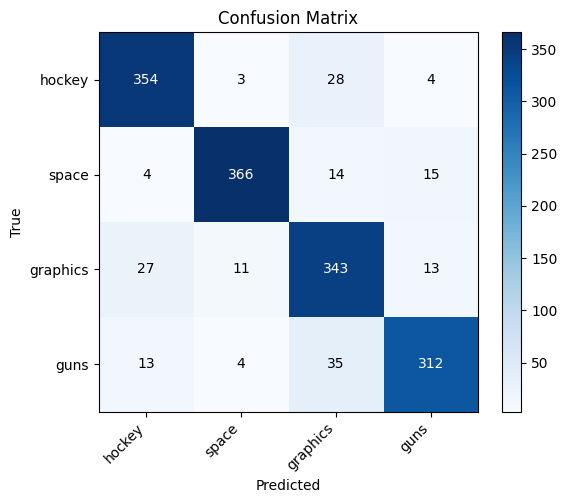

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_data.target, preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
short_names = [c.split('.')[-1] for c in categories]
ax.set_xticks(range(len(categories)))
ax.set_yticks(range(len(categories)))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
for i in range(len(categories)):
    for j in range(len(categories)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 4. TF-IDF

```
TF(t, d)  = count(t in d) / len(d)
IDF(t)    = log(N / df(t))   # N=total docs, df=docs with term
TF-IDF    = TF × IDF
```

Words in every doc (like 'the') get IDF ≈ 0 → low TF-IDF.
Rare but important words get high IDF → high TF-IDF.

## Practice Exercises

See **`Lecture-05-Homework.ipynb`** for the practice exercises accompanying this lecture.

In [9]:
import math

docs = [
    'the cat sat on the mat',
    'the dog sat on the log',
    'the cat chased the dog'
]

def tfidf(word, doc, all_docs):
    tf = doc.split().count(word) / len(doc.split())
    n_docs_with_word = sum(1 for d in all_docs if word in d.split())
    idf = math.log(len(all_docs) / (1 + n_docs_with_word))
    return tf * idf

vocab = sorted(set(w for d in docs for w in d.split()))
print(f'{"Word":12s}  doc1    doc2    doc3')
print('-' * 45)
for word in vocab:
    scores = [f'{tfidf(word, d, docs):.4f}' for d in docs]
    print(f'{word:12s}  {"  ".join(scores)}')

Word          doc1    doc2    doc3
---------------------------------------------
cat           0.0000  0.0000  0.0000
chased        0.0000  0.0000  0.0811
dog           0.0000  0.0000  0.0000
log           0.0000  0.0676  0.0000
mat           0.0676  0.0000  0.0000
on            0.0000  0.0000  0.0000
sat           0.0000  0.0000  0.0000
the           -0.0959  -0.0959  -0.1151


## Summary

| Concept | Key Point |
|---------|----------|
| Feature extraction | Convert text to numerical features |
| Naive Bayes | Fast, probabilistic, great baseline |
| TF-IDF | Rewards distinctive words |
| scikit-learn Pipeline | Clean vectorizer + classifier combo |
| Evaluation | Accuracy, Precision, Recall, F1 |

**Next Lecture**: Sequence Processing & Tagging — POS tagging, chunking, NER.

---
*Book references: NLP with Python Ch.6 | Practical NLP Ch.4*

---
**Author: Lei Wu | © 2026 Lei Wu. All rights reserved. Unauthorized use is prohibited.**